<a href="https://colab.research.google.com/github/Franciielly/rede-neural-celsius-fahrenheit/blob/main/redeNeural_celsius.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Numpy = utilizado para cálculos matematicos

Matplotlib = utilizado para exibir gráficos

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Definindo estilo e altura do gráfico:

In [3]:
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (10,8)

# **Criar o dataset**

O dataset **prevê a temperatura em fahrenheit**

**Eixo X** = temperatura em Celsius

**Eixo Y** = temperatura em fahrenheit

x = temperatura de Celsius

w = inclinação da reta

b = bias (ponto que cruza eixo y)

noise_scale = o ruído (para ser treinado com dados imperfeitos)

In [14]:
def curva_linear (x, w, b = 0, noise_scale = 0):
  return w*x + b + noise_scale * np.random.randn(x.shape[0])  #Equação da reta

Criando dados com numpy (números de -10 a perto de 31, de 0.5 em 0.5)

Exemplo de dados de entrada(feature): -10, -9.5, -9.0, ..., 29.5, 30.0

In [15]:
x = np.arange(-10, 31, 0.5)

Criando dados de saída (Y)

*   x → os valores de entrada
*  1.8 → valor do w (inclinação)
*   32 → valor do b (ponto que cruza o eixo y)
*   2.5 → quantidade de ruído

In [16]:
Y = curva_linear(x, 1.8, 32, noise_scale = 2.5)

Shape = quantos elementos tem e como estão organizado

Por exemplo:  
(82,) → 82 valores em um vetor

(82, 1) → 82 linhas e 1 coluna

(82, 2) → 82 linhas e 2 colunas


In [17]:
x.shape, Y.shape

((82,), (82,))

Criando gráfico de dispersão (é um gráfico que mostra pontos no plano)

Text(0, 0.5, '°F')

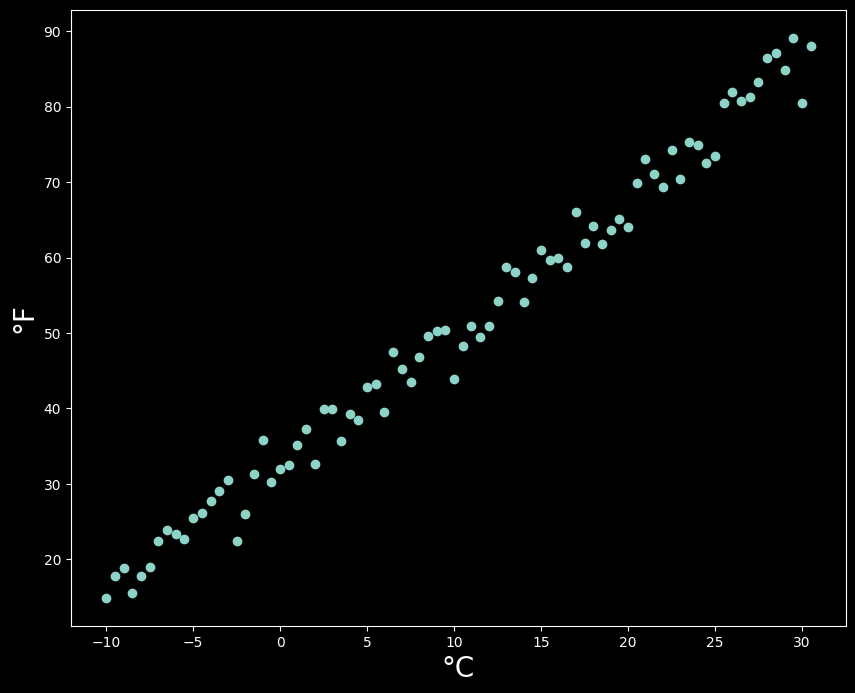

In [18]:
plt.scatter(x, Y)
plt.xlabel("°C", fontsize = 20)
plt.ylabel("°F", fontsize = 20)

Modelo
- Inicializar os pesos e bias
- Feedforward
- Calcular a perda
- Backpropagation

inicializando W e B

In [19]:
w = np.random.rand(1)
b = 0

Criando equação da reta

In [20]:
def forward(entrada, w, b):
  return w*entrada + b

Criando função de perda
MSE = Mean Squared Error (Erro quadrático médio)

Calculando o erro entre:

Y → valor real (do dataset)

y → valor previsto pelo modelo

E depois elevando ao quadrado.

In [21]:
def mse(Y, y):
  return(Y-y) ** 2

**Derivada** é o quanto uma coisa muda em relação a outra.

Backpropagation: atualizar pesos

Target = valor real do dataset (Y)

lr = o tamanho do passo que o modelo dá ao ajustar w e b (taxa de aprendizagem)


In [39]:
def backpropagation(entrada, saida, target, w, b, lr):
  dw = lr*(-2*entrada*(target - saida)).mean()
  db = lr*(-2*(target - saida)).mean()

  w -= dw
  b -= db

  return w, b

Epochs = quantas vezes vai rodar o banco de dados

In [81]:
def model_fit(entrada, target, w , b, epochs = 200, lr = 0.001):
  for epoch in range(epochs):
    saida = forward(entrada, w , b)
    loss = np.mean(mse(target, saida))
    w, b = backpropagation(entrada, saida, target, w, b, lr)

    if (epoch + 1) % (epochs/10) == 0:
      print(f"Epoch: [{(epoch + 1)}/{epochs}] Perda: [{loss:.4f}]")

  return w, b

In [82]:
x = np.arange(-10, 30, 0.5)
Y = curva_linear(x, w = 1.8, b = 32, noise_scale= 2.5)

In [86]:
#Inicialização
w = np.random.randn(1)
b = np.zeros(1)     #arrays com zero e uma dimensão
print(f"W inicial: {w.item():.3f}, B = {b.item():.3f}")

W inicial: -0.103, B = 0.000


In [87]:
w, b = model_fit(x, Y, w, b, epochs= 2500, lr = 0.002)
print(f"W = {w.item():.3f}, B = {b.item():.3f}")

Epoch: [250/2500] Perda: [191.8370]
Epoch: [500/2500] Perda: [64.4507]
Epoch: [750/2500] Perda: [24.7843]
Epoch: [1000/2500] Perda: [12.4326]
Epoch: [1250/2500] Perda: [8.5865]
Epoch: [1500/2500] Perda: [7.3889]
Epoch: [1750/2500] Perda: [7.0159]
Epoch: [2000/2500] Perda: [6.8998]
Epoch: [2250/2500] Perda: [6.8637]
Epoch: [2500/2500] Perda: [6.8524]
W = 1.774, B = 31.872


Text(0.5, 1.0, 'Rede Neural - Celsius para Fahrenheit')

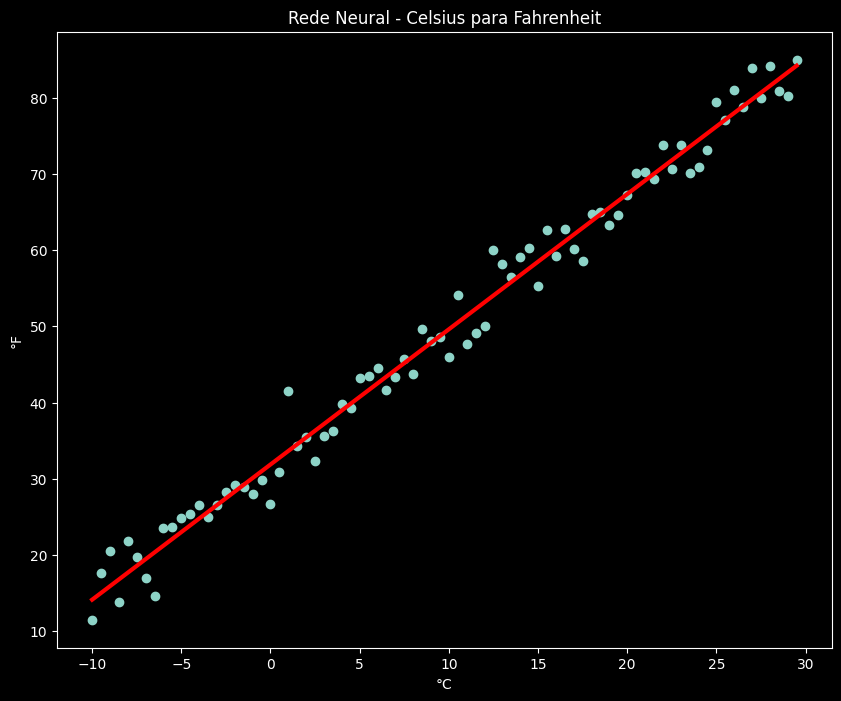

In [89]:
plt.scatter(x, Y)
plt.plot(x, curva_linear(x, w, b), 'r', lw = 3)
plt.xlabel("°C")
plt.ylabel("°F")
plt.title("Rede Neural - Celsius para Fahrenheit")